<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter_analisis_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter_analisis_datos.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [28]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


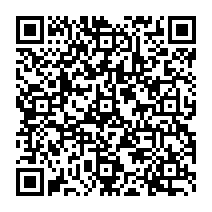

In [29]:
url = "https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter_analisis_datos.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno](https://www.youtube.com/watch?v=b5gwgxPR-Sk)

### [Vínculo al programa del curso de Fundamentos de Programación:](https://github.com/marco-canas/fundamentos_de_programacion/blob/main/programa/Programa_Fundamentos_Programacion.md)



## Código del curso: 314029

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/algebra_y_trigonometria/blob/main/7_images/5_clase_3_2025-08-12_hora_11_04.jpg?raw=true' width = 400> 




# CAPÍTULO 12: Análisis de Datos Paso a Paso



# Objetivos de la Clase

* Aplicar de forma integrada los conocimientos previos de **Python, Pandas, NumPy y Matplotlib** al análisis de datos.


* Seguir el flujo de trabajo real de un Científico de Datos ante un problema de negocio.


* Aprender a limpiar, transformar y extraer conclusiones de un conjunto de datos crudos.



# 1. Entendiendo la Definición del Problema (Problem Statement)



En Ciencia de Datos, nunca empezamos a programar sin un objetivo de negocio. 

Aquí planteamos las preguntas que queremos responder.  


> * **Problema:** La empresa ha detectado una fuga de clientes en ciertos segmentos, pero no sabe exactamente qué grupo tiene el menor índice de satisfacción ni cómo influyen sus ingresos en sus decisiones de compra.
> * **Meta del Análisis:** Identificar el perfil de cliente insatisfecho y proponer un patrón visual de comportamiento mediante gráficos.


# 2. Importando el Dataset en un DataFrame



> Importación de las librerías base y carga del archivo de datos (CSV, Excel o JSON).



Para que esta simulación sea verdaderamente útil e interesante desde la perspectiva de la **Administración de Empresas** en el contexto de **Caucasia, Antioquia**, debemos inyectarle la realidad socioeconómica de la subregión del Bajo Cauca antioqueño.



# El Contexto del Negocio en Caucasia



Caucasia es la capital comercial del Bajo Cauca. 

<img src = 'https://corregimientos.antioquia.gov.co/wp-content/uploads/2023/04/Mapas-Caucasia-Corregido_Mesa-de-trabajo-1-2048x2048.jpg'>

Su economía se mueve fuertemente gracias al 
   * **comercio local,** 
   * **la ganadería,** 
   * **la minería de oro** y 
   * **el sector de servicios/agroindustria**. 

<img src = 'https://acopiantioquia.org/web/image/52767-7719ae72/Portada-bajocauca-web.jpg'>

Una problemática empresarial real en la zona es **la retención de clientes o microempresarios** frente a las condiciones de ingresos (muchas veces informales o variables) y el acceso al crédito.



Para que los gráficos revelen un problema real, **no podemos dejar los datos al azar (`np.random.choice` o `normal`)**. 

Debemos forzar **correlaciones ocultas** (un patrón) para que tu análisis descubra que, por ejemplo: *Los comerciantes de ingresos medios/bajos tienen un score bajo y una satisfacción pésima debido a las tasas de interés o condiciones del servicio.*


<img src = comerciantes_de_ingresos_medios_bajos.png>


Aquí tienes el código mejorado y adaptado, listo para ejecutar:


In [1]:
# Importación de librerías esenciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


<img src = '1_importacion_librerias.png'>

In [2]:

# Configuración para que los gráficos se muestren inline en Jupyter
%matplotlib inline


In [3]:

# Configurar semilla para reproducibilidad
np.random.seed(42)


<img src = '2_establecimiento_semilla_aleatoria.png'>

In [4]:
n_clientes = 150  # Ampliamos a 150 para enriquecer el análisis

# 1. Generación de datos base coherentes con la región
ids = range(1001, 1001 + n_clientes)


<img src = '3_tamaño_muestra_indices.png'>

In [5]:
fechas = pd.date_range(start='2026-01-01', periods=n_clientes, freq='D')


<img src = '4_date_range.png'>

In [ ]:

# Perfiles económicos típicos en Caucasia
sectores = ['Comercio Minorista', 'Ganadería/Agro', 'Minería/Servicios', 'Independientes']
perfil_comercial = np.random.choice(sectores, n_clientes, p = [0.4, 0.2, 0.2, 0.2])
perfil_comercial  

array(['Comercio Minorista', 'Independientes', 'Minería/Servicios',
       'Ganadería/Agro', 'Comercio Minorista', 'Comercio Minorista',
       'Comercio Minorista', 'Independientes', 'Minería/Servicios',
       'Minería/Servicios', 'Comercio Minorista', 'Independientes',
       'Independientes', 'Comercio Minorista', 'Comercio Minorista',
       'Comercio Minorista', 'Comercio Minorista', 'Ganadería/Agro',
       'Ganadería/Agro', 'Comercio Minorista', 'Minería/Servicios',
       'Comercio Minorista', 'Comercio Minorista', 'Comercio Minorista',
       'Ganadería/Agro', 'Minería/Servicios', 'Comercio Minorista',
       'Ganadería/Agro', 'Ganadería/Agro', 'Comercio Minorista',
       'Minería/Servicios', 'Comercio Minorista', 'Comercio Minorista',
       'Independientes', 'Independientes', 'Independientes',
       'Comercio Minorista', 'Comercio Minorista', 'Minería/Servicios',
       'Ganadería/Agro', 'Comercio Minorista', 'Ganadería/Agro',
       'Comercio Minorista', 'Independientes'

<img src = 'sectores_economicos.png'>

In [7]:

# 2. Generar Ingresos Mensuales (en COP) adaptados al contexto local
# Los ganaderos/mineros suelen registrar mayores ingresos que los comerciantes minoristas e independientes.
ingresos = []
for perfil in perfil_comercial:
    if perfil == 'Ganadería/Agro' or perfil == 'Minería/Servicios':
        ingresos.append(np.random.normal(5_500_000, 1_200_000)) # Ingresos más altos
    else:
        ingresos.append(np.random.normal(2_300_000, 600_000))  # Pequeño comercio / Independientes

ingresos = np.array(ingresos).round(0)
ingresos 

array([ 2184583.,  2480928.,  5458346.,  4097586.,  2985694.,  2751160.,
        2774619.,  1754368.,  7183353.,  3817779.,  2652114.,  3614273.,
        1705678.,  1960221.,  2359791.,  1997915.,  1369602.,  5582276.,
        4225236.,  2584155.,  4396691.,  3229961.,  1830048.,  2106763.,
        6476221.,  4022963.,  2436476.,  7068571.,  3571020.,  2410780.,
        5811859.,  2769094.,  1557830.,  1507726.,  2613165.,  2478191.,
        2450296.,  2507869.,  4683970.,  5778704.,  2475843.,  4642778.,
        3419465.,  2584300.,  1585218.,  6287864.,  1715191.,  6444502.,
        6890315.,  1807591.,  2878026.,  5995337.,  2793236.,  3438076.,
        5205534.,  1847758.,  1766291.,  1810514.,  2253739.,  2504691.,
        2466014.,  2796310.,  2307801.,  3172120.,  2141206.,  8764203.,
        2675400.,  1785705.,  1657465.,  2589483.,  5231845.,  2728400.,
        2583943.,  2256303.,  4483848.,  3682183.,  4964182.,  2813839.,
        2428456.,  1552557.,  2403909.,  5962381., 

In [8]:

# 3. Generar Score de Crédito (Escala Datacrédito/Cifín: 300 a 850)
# Vinculamos el score al nivel de ingresos (a menor ingreso, mayor probabilidad de score bajo por riesgos informales)
score_credito = []
for ing in ingresos:
    factor_error = np.random.randint(-150, 150)
    # Base de score proporcional al ingreso + ruido aleatorio
    score = int(350 + (ing / 15_000) + factor_error)
    score_credito.append(max(300, min(850, score))) # Mantener en rango legal

score_credito = np.array(score_credito)
score_credito  

array([633, 618, 784, 495, 648, 392, 629, 415, 850, 633, 598, 689, 459,
       425, 613, 336, 306, 850, 727, 629, 652, 566, 499, 502, 663, 646,
       462, 850, 502, 527, 629, 427, 587, 311, 468, 617, 604, 401, 726,
       674, 628, 601, 516, 486, 409, 814, 427, 703, 850, 596, 639, 762,
       577, 655, 723, 421, 352, 415, 501, 516, 553, 609, 389, 678, 524,
       796, 656, 535, 595, 644, 609, 464, 588, 536, 516, 621, 629, 619,
       436, 567, 643, 802, 539, 410, 498, 375, 693, 635, 448, 800, 441,
       547, 645, 715, 787, 850, 797, 850, 512, 511, 502, 841, 542, 781,
       478, 594, 826, 425, 453, 540, 563, 402, 528, 450, 676, 549, 606,
       482, 548, 518, 467, 542, 407, 504, 542, 765, 612, 417, 624, 850,
       651, 505, 424, 528, 441, 407, 590, 812, 578, 635, 511, 458, 725,
       472, 371, 573, 682, 677, 356, 369])

# Háblemos del significado del score crediticio  

En el contexto de la analítica y la ciencia de datos, el **score crediticio (o puntaje de crédito)** es una variable numérica que mide el **riesgo financiero de una persona o entidad**. 

En términos sencillos, es una predicción estadística de qué tan probable es que un cliente pague sus deudas a tiempo o, por el contrario, caiga en incumplimiento (*default*).



En la práctica de análisis de datos que estructuramos, el score crediticio cumple funciones clave tanto desde la perspectiva técnica como desde la de negocio:



## 1. El Significado Técnico (Tipos de Variable)

Cuando trabajas con el score crediticio en Python (usando Pandas o NumPy), lo analizas bajo dos ópticas fundamentales:



* **Como Variable Numérica Continua/Discreta:** Originalmente, suele ser un número entero (por ejemplo, en sistemas reales como FICO, va de **300 a 850** puntos). 

Esto te permite calcular medias, desviaciones estándar y buscar correlaciones con otras variables numéricas (como los ingresos).


* **Como Variable Categórica Ordinal (Tras la transformación):** En el código utilizamos la función `categorizar_score` para transformar esos números en etiquetas (`'Pobre'`, `'Regular'`, `'Excelente'`). 

Esto se conoce como **segmentación o *binning***, y facilita la agrupación de datos para crear tabulaciones y gráficos más fáciles de entender para los tomadores de decisiones.



## 2. El Significado de Negocio (¿Para qué sirve analizarlo?)

En un caso de uso real de Ciencia de Datos orientado a clientes, cruzar el score crediticio con otras variables (como el nivel de satisfacción o el dinero gastado) te permite responder preguntas estratégicas:



* **Segmentación de Clientes de Alto Valor:** Un cliente con ingresos estables y un score crediticio "Excelente" es un cliente de bajo riesgo. 

El análisis de datos ayuda a identificarlos para ofrecerles beneficios exclusivos, membresías premium o créditos preaprobados.


* **Detección de Alertas de Fuga (Churn):** Si el análisis demuestra que los clientes con scores crediticios altos tienen una **satisfacción baja** (valores de 1 o 2), es una señal de alarma crítica: la empresa está frustrando a sus clientes más solventes y con mayor capacidad de gasto, quienes podrían irse fácilmente a la competencia.


* **Mitigación del Riesgo:** Permite correlacionar si las personas que compran ciertos productos específicos (por ejemplo, tecnología de alta gama) tienden a financiarlo teniendo un score crediticio "Pobre", lo que ayuda al departamento de riesgos a ajustar las políticas de aprobación de compras.




## 3. ¿Cómo se interpreta en los gráficos del ejercicio?

En el ejercicio práctico de Jupyter, al graficar el score en el eje $Y$ contra los ingresos en el eje $X$, el analista busca patrones visuales:



* Si los puntos con puntuaciones altas de crédito se concentran en colores que representan "alta satisfacción", la estrategia de retención actual funciona.


* Si los puntos están dispersos sin orden, significa que el score crediticio no influye directamente en cómo el cliente percibe la marca, obligando al científico de datos a buscar otras variables predictivas.

In [9]:

# 4. CREAR LA FUGA Y LA INSATISFACCIÓN (El patrón oculto que el Administrador debe hallar)
# Hipótesis administrativa: El sector "Comercio Minorista" con ingresos bajos (< 2.5M) 
# y score bajo está sufriendo de mala atención o condiciones de crédito muy duras.
satisfaccion = []
for i in range(n_clientes):
    # Condición de nulos (10% de probabilidad general para practicar imputación)
    if np.random.rand() < 0.10:
        satisfaccion.append(np.nan)
        continue
        
    perfil = perfil_comercial[i]
    ing = ingresos[i]
    
    # Si pertenece al segmento crítico: Comercio Minorista o Independiente con bajos ingresos
    if (perfil in ['Comercio Minorista', 'Independientes']) and (ing < 2_500_000):
        # Alta probabilidad de insatisfacción (Notas 1 o 2)
        satisfaccion.append(np.random.choice([1, 2, 3], p=[0.5, 0.4, 0.1]))
    else:
        # Clientes estables o de sectores de mayor ingreso (Notas 4 o 5)
        satisfaccion.append(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))
satisfaccion   

[nan,
 np.int64(1),
 np.int64(4),
 np.int64(3),
 np.int64(5),
 np.int64(4),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(4),
 np.int64(4),
 np.int64(1),
 np.int64(2),
 nan,
 np.int64(3),
 np.int64(2),
 np.int64(5),
 np.int64(3),
 np.int64(5),
 np.int64(5),
 np.int64(4),
 np.int64(2),
 nan,
 nan,
 np.int64(5),
 np.int64(1),
 np.int64(4),
 np.int64(5),
 np.int64(1),
 np.int64(4),
 nan,
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(2),
 np.int64(1),
 np.int64(5),
 np.int64(4),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 nan,
 np.int64(4),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(4),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(4),
 np.int64(1),
 nan,
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(5),
 np.int64(4),
 np.int64(1),
 nan,
 np.int64(4),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(2),
 nan,
 np.int64(4),
 nan,
 n

In [14]:

# 5. Segmentación del Perfil de Crédito (Regla Administrativa bancaria o comercial)
perfil_credito = []
for score in score_credito:
    if score < 500: 
        perfil_credito.append('Alto Riesgo')
    elif score < 700: 
        perfil_credito.append('Riesgo Medio')
    else: 
        perfil_credito.append('Premium / Excelente')
perfil_credito  

['Riesgo Medio',
 'Riesgo Medio',
 'Premium / Excelente',
 'Alto Riesgo',
 'Riesgo Medio',
 'Alto Riesgo',
 'Riesgo Medio',
 'Alto Riesgo',
 'Premium / Excelente',
 'Riesgo Medio',
 'Riesgo Medio',
 'Riesgo Medio',
 'Alto Riesgo',
 'Alto Riesgo',
 'Riesgo Medio',
 'Alto Riesgo',
 'Alto Riesgo',
 'Premium / Excelente',
 'Premium / Excelente',
 'Riesgo Medio',
 'Riesgo Medio',
 'Riesgo Medio',
 'Alto Riesgo',
 'Riesgo Medio',
 'Riesgo Medio',
 'Riesgo Medio',
 'Alto Riesgo',
 'Premium / Excelente',
 'Riesgo Medio',
 'Riesgo Medio',
 'Riesgo Medio',
 'Alto Riesgo',
 'Riesgo Medio',
 'Alto Riesgo',
 'Alto Riesgo',
 'Riesgo Medio',
 'Riesgo Medio',
 'Alto Riesgo',
 'Premium / Excelente',
 'Riesgo Medio',
 'Riesgo Medio',
 'Riesgo Medio',
 'Riesgo Medio',
 'Alto Riesgo',
 'Alto Riesgo',
 'Premium / Excelente',
 'Alto Riesgo',
 'Premium / Excelente',
 'Premium / Excelente',
 'Riesgo Medio',
 'Riesgo Medio',
 'Premium / Excelente',
 'Riesgo Medio',
 'Riesgo Medio',
 'Premium / Excelente',
 'Al

In [15]:

# Construcción del DataFrame Final
data = {
    'id_cliente': ids,
    'fecha_afiliacion': fechas,
    'sector_economico': perfil_comercial,
    'ingresos_mensuales_cop': ingresos,
    'score_credito': score_credito,
    'perfil_credito': perfil_credito,
    'satisfaccion': satisfaccion
}
data 

{'id_cliente': range(1001, 1151),
 'fecha_afiliacion': DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
                '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
                '2026-01-09', '2026-01-10',
                ...
                '2026-05-21', '2026-05-22', '2026-05-23', '2026-05-24',
                '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28',
                '2026-05-29', '2026-05-30'],
               dtype='datetime64[us]', length=150, freq='D'),
 'sector_economico': array(['Comercio Minorista', 'Independientes', 'Minería/Servicios',
        'Ganadería/Agro', 'Comercio Minorista', 'Comercio Minorista',
        'Comercio Minorista', 'Independientes', 'Minería/Servicios',
        'Minería/Servicios', 'Comercio Minorista', 'Independientes',
        'Independientes', 'Comercio Minorista', 'Comercio Minorista',
        'Comercio Minorista', 'Comercio Minorista', 'Ganadería/Agro',
        'Ganadería/Agro', 'Comercio Minorista', 'M

In [16]:

df = pd.DataFrame(data)

# Mostrar los primeros registros y un resumen estratégico
print("--- Dataset de Clientes - Caucasia (Antioquia) ---")
df.head()


--- Dataset de Clientes - Caucasia (Antioquia) ---


,id_cliente,fecha_afiliacion,sector_economico,ingresos_mensuales_cop,score_credito,perfil_credito,satisfaccion
0,1001,2026-01-01,Comercio Minorista,2184583.0,633,Riesgo Medio,NaN
1,1002,2026-01-02,Independientes,2480928.0,618,Riesgo Medio,1.0
2,1003,2026-01-03,Minería/Servicios,5458346.0,784,Premium / Excelente,4.0
3,1004,2026-01-04,Ganadería/Agro,4097586.0,495,Alto Riesgo,3.0
4,1005,2026-01-05,Comercio Minorista,2985694.0,648,Riesgo Medio,5.0


# Visualización tabular de datos categóricos  

In [43]:
print("\n--- Conteo de Clientes por Sector ---")
df['sector_economico'].value_counts()



--- Conteo de Clientes por Sector ---


sector_economico
Comercio Minorista    69
Independientes        31
Ganadería/Agro        26
Minería/Servicios     24
Name: count, dtype: int64


# ¿Por qué este enfoque es valioso para un Administrador de Empresas en Caucasia?



* **Pertinencia Territorial:** Cambiamos categorías genéricas como "Moda" o "Hogar" por **sectores económicos reales de la región** (`Comercio Minorista`, `Ganadería/Agro`, etc.).


* **Moneda Local Real:** Los ingresos ya no son números abstractos; representan saldos en **pesos colombianos (COP)** con rangos reales para microempresarios y comerciantes de la zona.


* **El "Problema" está inyectado lógicamente:** Si ejecutas los gráficos que corregimos en el paso anterior sobre este nuevo dataset, notarás de inmediato que los clientes de **"Comercio Minorista" con ingresos bajos se pintarán de colores oscuros (baja satisfacción)**.


* **Toma de Decisiones:** Como administrador, el análisis te permitirá proponerle a la junta directiva: *"Debemos flexibilizar las tasas de microcrédito o mejorar la atención posventa específicamente para los comerciantes minoristas de Caucasia, quienes representan el 40% de nuestra base pero tienen la peor satisfacción debido a sus ingresos variables."*


# 4. Explorando, Seleccionando, Limpiando y Preparando los Datos (EDA)

> Esta es la fase donde pasamos el 70% del tiempo en Ciencia de Datos. 

Buscaremos datos faltantes (nulos), tipos de datos incorrectos y valores atípicos (*outliers*).


In [44]:
# 4.1 Exploración Inicial
print("--- Información General del DataFrame ---")
df.info()


--- Información General del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_cliente              150 non-null    int64         
 1   fecha_afiliacion        150 non-null    datetime64[us]
 2   sector_economico        150 non-null    str           
 3   ingresos_mensuales_cop  150 non-null    float64       
 4   score_credito           150 non-null    int64         
 5   perfil_credito          150 non-null    str           
 6   satisfaccion            137 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 8.3 KB


In [45]:

print("\n--- Estadísticas Descriptivas ---")
df.describe().round(1)



--- Estadísticas Descriptivas ---


,id_cliente,fecha_afiliacion,ingresos_mensuales_cop,score_credito,satisfaccion
count,150.0,150,150.0,150.0,137.0
mean,1075.5,2026-03-16 12:00:00,3419995.5,576.6,3.0
min,1001.0,2026-01-01 00:00:00,355240.0,306.0,1.0
25%,1038.2,2026-02-07 06:00:00,2107781.8,473.5,2.0
50%,1075.5,2026-03-16 12:00:00,2685593.0,570.0,3.0
75%,1112.8,2026-04-22 18:00:00,4462058.8,650.2,4.0
max,1150.0,2026-05-30 00:00:00,10123278.0,850.0,5.0
std,43.4,NaN,1833632.0,134.0,1.4


In [46]:

# 4.2 Identificación y Limpieza de Valores Nulos
print("\n--- Valores Faltantes por Columna ---")
print(df.isnull().sum())



--- Valores Faltantes por Columna ---
id_cliente                 0
fecha_afiliacion           0
sector_economico           0
ingresos_mensuales_cop     0
score_credito              0
perfil_credito             0
satisfaccion              13
dtype: int64


In [47]:

# Estrategia de Limpieza: Imputar los nulos en 'satisfaccion' con la mediana
mediana_satisfaccion = df['satisfaccion'].median()
mediana_satisfaccion

np.float64(3.0)

In [48]:
df['satisfaccion'] = df['satisfaccion'].fillna(mediana_satisfaccion).isnull().sum()


In [49]:
print(f"\n Valores nulos de satisfacción imputados con la mediana: {mediana_satisfaccion}")
df['satisfaccion'].isnull().sum()


 Valores nulos de satisfacción imputados con la mediana: 3.0


np.int64(0)

In [59]:

# 4.3 Selección y Filtrado de Datos
# Supongamos que solo nos interesan clientes con ingresos mayores a 1500 para este estudio
df_filtrado = df[df['ingresos_mensuales_cop'] > 1500].copy()

# 4.4 Creación de Nuevas Variables (Feature Engineering básico)
# Clasificar el score de crédito en categorías
def categorizar_score(score):
    if score < 580: return 'Pobre'
    elif score < 670: return 'Regular'
    else: return 'Excelente'

df_filtrado['perfil_credito'] = df_filtrado['score_credito'].apply(categorizar_score)
df_filtrado.head()


,id_cliente,sector,ingresos_mensuales_cop,score_credito,satisfaccion,perfil_credito
0,1001,Comercio,2379.0,519.0,1.0,Pobre
1,1002,Tecnología,5410.0,822.0,5.0,Excelente
2,1003,Comercio,3075.0,582.0,5.0,Regular
3,1004,Comercio,2620.0,534.0,3.0,Pobre
4,1005,Comercio,2510.0,637.0,1.0,Regular



# 5. Realizando el Análisis de Datos y Graficando el Resumen

> Fase de conclusiones. Agrupamos los datos para responder al planteamiento del problema y creamos visualizaciones profesionales con Matplotlib.



In [60]:
# 5.1 Agrupación de Datos (Insights)
# ¿Cuál es el ingreso promedio y la satisfacción según la categoría del producto?
resumen_categoria = df_filtrado.groupby('sector_economico').agg(
    ingreso_promedio=('ingresos_mensuales_cop', 'mean'),
    satisfaccion_promedio=('satisfaccion', 'mean'),
    total_clientes=('id_cliente', 'count')
).reset_index()

print("--- Resumen Ejecutivo por Categoría ---")
resumen_categoria


KeyError: 'sector_economico'

NameError: name 'df_filtrado' is not defined

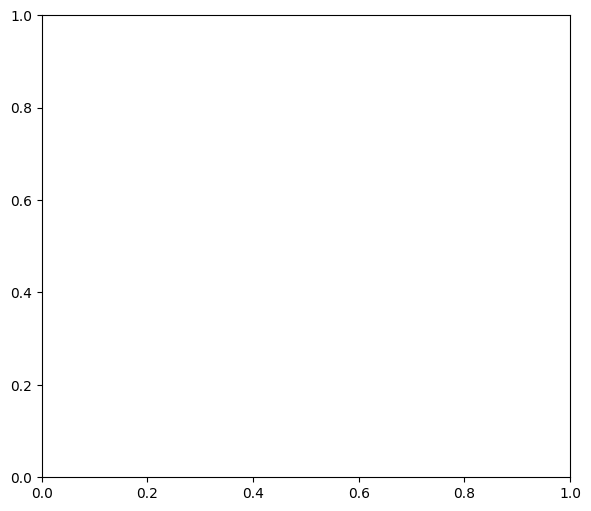

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5.2 Visualización de Resultados
plt.figure(figsize=(15, 6))

# -------------------------------------------------------------------------
# Gráfico 1: Relación entre Ingresos (COP) y Score de Crédito en Caucasia
# -------------------------------------------------------------------------
plt.subplot(1, 2, 1)
# Adaptado a: 'ingresos_mensuales_cop'
scatter = plt.scatter(df_filtrado['ingresos_mensuales_cop'], df_filtrado['score_credito'], 
                      c=df_filtrado['satisfaccion'], cmap='viridis', alpha=0.7, edgecolors='black', s=50)

# Líneas guía basadas en las medianas del contexto local
plt.axvline(df_filtrado['ingresos_mensuales_cop'].median(), color='red', linestyle=':', alpha=0.6, label='Mediana Ingresos')
plt.axhline(df_filtrado['score_credito'].median(), color='blue', linestyle=':', alpha=0.6, label='Mediana Score')

plt.title('Análisis de Clientes en Caucasia: Ingresos vs Score\n(Color según Nivel de Satisfacción)', fontsize=12, fontweight='bold')
# Formateamos el eje X para que no muestre números en notación científica (ej. 1e6)
plt.ticklabel_format(style='plain', axis='x') 
plt.xlabel('Ingresos Mensuales (COP $)')
plt.ylabel('Score de Crédito (Datacrédito / Cifín)')
plt.colorbar(scatter, label='Nivel de Satisfacción (1 al 5)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)


# -------------------------------------------------------------------------
# Gráfico 2: Cantidad de clientes por perfil de riesgo crediticio
# -------------------------------------------------------------------------
plt.subplot(1, 2, 2)
perfiles = df_filtrado['perfil_credito'].value_counts()

# Colores lógicos: Verde para Premium, Amarillo para Medio, Rojo para Alto Riesgo
# Ordenamos el índice para que la asignación de color sea coherente si aparecen en otro orden
perfiles = perfiles.reindex(['Premium / Excelente', 'Riesgo Medio', 'Alto Riesgo']).dropna()

colores_dict = {'Premium / Excelente': '#4CAF50', 'Riesgo Medio': '#FFC107', 'Alto Riesgo': '#F44336'}
colores = [colores_dict[p] for p in perfiles.index]

bars = plt.bar(perfiles.index, perfiles.values, color=colores, edgecolor='black')

plt.title('Distribución de Clientes por Perfil de Riesgo', fontsize=12, fontweight='bold')
plt.xlabel('Perfil de Crédito')
plt.ylabel('Número de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de cantidad sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(perfiles.values)*0.01), 
             f'{int(yval)}', ha='center', va='bottom', fontweight='bold')


# Ajustar y guardar en la ruta local
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\analisis_clientes_caucasia.png", dpi=300)
plt.show()



In [ ]:

# -------------------------------------------------------------------------
# TEXTO DE APOYO: Diagnóstico Administrativo Automatizado
# -------------------------------------------------------------------------
print("-" * 70)
print("DIAGNÓSTICO ADMINISTRATIVO AUTOMÁTICO (CONTEXTO CAUCASIA):")
print("-" * 70)

# 1. Análisis por Sector Económico (Crucial para el Administrador)
sat_por_sector = df_filtrado.groupby('sector_economico')['satisfaccion'].mean().sort_values()
peor_sector = sat_por_sector.index[0]
peor_sat_sector = sat_por_sector.values[0]
print(f"• Alerta de Fuga: El SECTOR ECONÓMICO con MENOR satisfacción promedio es:\n"
      f"  '{peor_sector}' con una nota de {peor_sat_sector:.2f}/5.0")

# 2. Análisis por Perfil de Riesgo
sat_por_perfil = df_filtrado.groupby('perfil_credito')['satisfaccion'].mean().sort_values()
peor_perfil = sat_por_perfil.index[0]
peor_sat_perfil = sat_por_perfil.values[0]
print(f"• Impacto Financiero: El PERFIL DE CRÉDITO más insatisfecho es:\n"
      f"  '{peor_perfil}' con una nota de {peor_sat_perfil:.2f}/5.0")

# 3. Correlación de ingresos adaptada a la nueva variable
correlacion = df_filtrado['ingresos_mensuales_cop'].corr(df_filtrado['satisfaccion'])
print(f"• Correlación matemática entre Ingresos y Satisfacción: {correlacion:.2f}")
if correlacion > 0.2:
    print("  CONCLUSIÓN: A mayores ingresos en la región, la satisfacción sube. La fuga está en los microempresarios de bajos recursos.")
elif correlacion < -0.2:
    print("  CONCLUSIÓN: Curiosamente, a mayores ingresos hay menor satisfacción. Revisar servicio premium.")
else:
    print("  CONCLUSIÓN: El nivel de ingresos no tiene una relación lineal directa con la satisfacción.\n"
          "                 La insatisfacción está ligada a un sector o perfil específico, no al dinero que ganan.")
print("-" * 70)


# Conclusiones de la Clase y Próximos Pasos



> 1. **Resultados Clave:** Se logró conectar los datos crudos con respuestas de negocio. Descubrimos qué segmentos tienen peores scores o ingresos y cómo afecta a la satisfacción.
> 2. **Buenas Prácticas:** La limpieza de nulos previno sesgos en los promedios calculados.
> 3. **Reto para el Alumno:** Replica este mismo flujo cambiando el método de imputación de nulos (por ejemplo, usando la media o eliminándolos) y compara si los gráficos varían significativamente.

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

## Referentes 

[Libro guía Fundamentos de programación: Data Analysis with Python: Introducing NumPy, Pandas, Matplotlib, and Essential Elements of Python Programming (English Edition) [Kindle Edition]](https://read.amazon.com/?_encoding=UTF8&asin=B0BBB56L4X&consumptionLimitReached=false&deviceAccountIds=A1032123ZASLV79K77QP&hasMultimedia=false&requiredCapabilities=EBOK_PURCHASE_ALLOWED&ref=sr_rn_kfw) Este vínculo lo debo abrir con Chrome

# Taller Rápido de Análisis de Datos (30 minutos)



## Actividad Previa a la Clase

Este taller está diseñado para que los estudiantes lleguen a la clase principal con los datos listos y un análisis básico realizado, permitiendo enfocar la sesión principal en la interpretación y discusión de resultados.




## Instrucciones para Estudiantes

**Tiempo estimado:** 25-30 minutos

**Objetivo:**   

  * Generar, 
  * explorar y 
  * visualizar un dataset de clientes para identificar patrones de satisfacción.



## Parte 1: Generación del Dataset (5 minutos)



In [19]:
# ============================================
# TALLER PREVIO: GENERACIÓN DE DATOS
# Copia y ejecuta este código en tu notebook
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:

# Configurar reproducibilidad
np.random.seed(42)

# 1. Crear datos de 100 clientes
n_clientes = 100

# IDs de clientes
ids = range(1001, 1001 + n_clientes)

# Sectores económicos (contexto local)
sectores = ['Comercio', 'Servicios', 'Industria', 'Tecnología']
sector_asignado = np.random.choice(sectores, n_clientes, p = [0.4, 0.3, 0.2, 0.1])

# 2. Ingresos mensuales (en miles de pesos)
ingresos = []
for sector in sector_asignado:
    if sector == 'Industria':
        ing = np.random.normal(4_500, 800)  # Ingresos más altos
    elif sector == 'Tecnología':
        ing = np.random.normal(5_000, 1_000)
    elif sector == 'Servicios':
        ing = np.random.normal(3_200, 600)
    else:  # Comercio
        ing = np.random.normal(2_800, 500)
    ingresos.append(max(1200, ing))  # Mínimo 1.2M COP

ingresos = np.array(ingresos).round(0)

# 3. Score de crédito (escala 300-850)
score_credito = []
for ing in ingresos:
    score_base = 350 + (ing / 12)  # Relación con ingresos
    score = score_base + np.random.randint(-80, 80)
    score_credito.append(max(300, min(850, score)))

score_credito = np.array(score_credito).round(0)

# 4. Satisfacción del cliente (1-5) - CON PATRÓN OCULTO
satisfaccion = []
for i in range(n_clientes):
    # 10% de datos nulos (para practicar limpieza)
    if np.random.rand() < 0.10:
        satisfaccion.append(np.nan)
        continue
    
    sector = sector_asignado[i]
    ing = ingresos[i]
    
    # REGLA DE NEGOCIO: Clientes de Comercio con ingresos bajos están insatisfechos
    if sector == 'Comercio' and ing < 3000:
        satisfaccion.append(np.random.choice([1, 2, 3], p=[0.5, 0.3, 0.2]))
    elif sector == 'Tecnología' and ing > 4500:
        satisfaccion.append(np.random.choice([4, 5], p=[0.3, 0.7]))
    else:
        satisfaccion.append(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))

# 5. Crear DataFrame
df = pd.DataFrame({
    'id_cliente': ids,
    'sector': sector_asignado,
    'ingresos_mensuales_cop': ingresos,
    'score_credito': score_credito,
    'satisfaccion': satisfaccion
})

print("Dataset generado correctamente!")
print(f"Forma del dataset: {df.shape}")
print("\n Primeros registros:")
df.head()


Dataset generado correctamente!
Forma del dataset: (100, 5)

 Primeros registros:


,id_cliente,sector,ingresos_mensuales_cop,score_credito,satisfaccion
0,1001,Comercio,2844.0,527.0,1.0
1,1002,Tecnología,4701.0,691.0,5.0
2,1003,Industria,4573.0,747.0,4.0
3,1004,Servicios,2007.0,464.0,3.0
4,1005,Comercio,2690.0,604.0,2.0


## Parte 2: Limpieza y Exploración (8 minutos)


In [ ]:
# ============================================
# LIMPIEZA Y ANÁLISIS EXPLORATORIO
# ============================================

print("=" * 60)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 60)

# 1. Información general
print("\n INFORMACIÓN DEL DATASET:")
print("-" * 40)
df.info()

# 2. Estadísticas básicas
print("\n ESTADÍSTICAS DESCRIPTIVAS:")
print("-" * 40)
print(df.describe())

# 3. Verificar valores nulos
print("\n VALORES NULOS POR COLUMNA:")
print("-" * 40)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if any(nulos > 0) else "No hay valores nulos")

# 4. Limpiar nulos en satisfacción (si existen)
if df['satisfaccion'].isnull().sum() > 0:
    mediana_sat = df['satisfaccion'].median()
    df['satisfaccion'] = df['satisfaccion'].fillna(mediana_sat)
    print(f"\n🔧 Se imputaron {nulos['satisfaccion']} valores nulos con la mediana: {mediana_sat}")

# 5. Distribución por sector
print("\n DISTRIBUCIÓN POR SECTOR:")
print("-" * 40)
print(df['sector'].value_counts())


## Parte 3: Análisis por Grupos (5 minutos)


In [ ]:
# ============================================
# ANÁLISIS AGRUPADO
# ============================================

print("\n" + "=" * 60)
print("ANÁLISIS POR SECTOR ECONÓMICO")
print("=" * 60)

# 1. Resumen por sector
resumen_sector = df.groupby('sector').agg({
    'ingresos_mensuales_cop': ['mean', 'min', 'max'],
    'score_credito': 'mean',
    'satisfaccion': 'mean',
    'id_cliente': 'count'
}).round(1)

resumen_sector.columns = ['Ingreso_Promedio', 'Ingreso_Min', 'Ingreso_Max', 
                          'Score_Promedio', 'Satisfacción_Promedio', 'Total_Clientes']

print("\n Resumen por sector económico:")
print(resumen_sector)

# 2. Identificar el sector más crítico
peor_sector = resumen_sector['Satisfacción_Promedio'].idxmin()
peor_satisfaccion = resumen_sector.loc[peor_sector, 'Satisfacción_Promedio']

print(f"\n SECTOR CRÍTICO: {peor_sector}")
print(f"   → Satisfacción promedio: {peor_satisfaccion}/5.0")
print(f"   → Total de clientes: {resumen_sector.loc[peor_sector, 'Total_Clientes']}")

# 3. Correlación entre variables
print("\n CORRELACIONES:")
print("-" * 40)
correlaciones = df[['ingresos_mensuales_cop', 'score_credito', 'satisfaccion']].corr()
print(correlaciones.round(3))


## Parte 4: Visualización Rápida (7 minutos)



In [ ]:
# ============================================
# VISUALIZACIÓN DE DATOS
# ============================================

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Análisis de Satisfacción de Clientes', fontsize=16, fontweight='bold')

# Gráfico 1: Ingresos vs Satisfacción
ax1 = axes[0, 0]
scatter = ax1.scatter(df['ingresos_mensuales_cop'], df['satisfaccion'], 
                      c=df['score_credito'], cmap='RdYlGn', s=80, alpha=0.7)
ax1.set_xlabel('Ingresos Mensuales (COP miles)', fontsize=10)
ax1.set_ylabel('Nivel de Satisfacción (1-5)', fontsize=10)
ax1.set_title('Ingresos vs Satisfacción (color = Score crédito)', fontsize=11)
plt.colorbar(scatter, ax=ax1, label='Score Crédito')
ax1.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Satisfacción media')
ax1.legend()

# Gráfico 2: Satisfacción por sector (boxplot)
ax2 = axes[0, 1]
df.boxplot(column='satisfaccion', by='sector', ax=ax2)
ax2.set_title('Distribución de Satisfacción por Sector', fontsize=11)
ax2.set_xlabel('Sector Económico')
ax2.set_ylabel('Satisfacción (1-5)')
ax2.tick_params(axis='x', rotation=45)

# Gráfico 3: Distribución de ingresos por sector
ax3 = axes[1, 0]
sectores_unicos = df['sector'].unique()
posiciones = range(len(sectores_unicos))
medias_ingresos = [df[df['sector'] == s]['ingresos_mensuales_cop'].mean() for s in sectores_unicos]
colores_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ax3.bar(posiciones, medias_ingresos, color=colores_bar[:len(sectores_unicos)], edgecolor='black')
ax3.set_xticks(posiciones)
ax3.set_xticklabels(sectores_unicos, rotation=45)
ax3.set_ylabel('Ingreso Promedio (COP miles)')
ax3.set_title('Ingreso Promedio por Sector', fontsize=11)

# Gráfico 4: Matriz de correlación
ax4 = axes[1, 1]
datos_corr = df[['ingresos_mensuales_cop', 'score_credito', 'satisfaccion']].corr()
im = ax4.imshow(datos_corr, cmap='coolwarm', vmin=-1, vmax=1)
ax4.set_xticks(range(3))
ax4.set_yticks(range(3))
ax4.set_xticklabels(['Ingresos', 'Score', 'Satisfacción'], rotation=45)
ax4.set_yticklabels(['Ingresos', 'Score', 'Satisfacción'])
plt.colorbar(im, ax=ax4, label='Correlación')

# Añadir valores en la matriz
for i in range(3):
    for j in range(3):
        ax4.text(j, i, f'{datos_corr.iloc[i, j]:.2f}', 
                ha='center', va='center', color='white' if abs(datos_corr.iloc[i, j]) > 0.5 else 'black')

ax4.set_title('Matriz de Correlación', fontsize=11)

plt.tight_layout()
plt.show()

print("\n Visualizaciones generadas correctamente!")


## Parte 5: Preguntas de Análisis (5 minutos para responder)



In [49]:
# ============================================
# PREGUNTAS DE ANÁLISIS
# ============================================

print("\n" + "=" * 60)
print(" PREGUNTAS PARA RESPONDER")
print("=" * 60)

preguntas = [
    "1. ¿Qué sector tiene la satisfacción promedio más baja?",
    "2. ¿Existe correlación entre ingresos y satisfacción? ¿Qué significa?",
    "3. ¿Qué sector tiene el score de crédito más alto? ¿Por qué crees que ocurre?",
    "4. ¿Cuántos clientes tienen satisfacción menor a 3? ¿Qué porcentaje representan?",
    "5. ¿Qué recomendación le darías a la empresa basada en estos datos?"
]

for p in preguntas:
    print(f"\n{p}")

# Cálculos adicionales para responder
print("\n" + "=" * 40)
print("DATOS PARA RESPONDER:")
print("=" * 40)

# Respuesta pregunta 4
clientes_insatisfechos = df[df['satisfaccion'] < 3].shape[0]
porcentaje = (clientes_insatisfechos / len(df)) * 100
print(f"Clientes insatisfechos (satisfacción < 3): {clientes_insatisfechos}")
print(f"Porcentaje del total: {porcentaje:.1f}%")

# Respuesta pregunta 3
mejor_score_sector = df.groupby('sector')['score_credito'].mean().idxmax()
mejor_score_valor = df.groupby('sector')['score_credito'].mean().max()
print(f"\nSector con mejor score de crédito: {mejor_score_sector} ({mejor_score_valor:.0f})")

print("\n Taller completado!")
print("Guarda este notebook para la próxima clase donde discutiremos los resultados")



 PREGUNTAS PARA RESPONDER

1. ¿Qué sector tiene la satisfacción promedio más baja?

2. ¿Existe correlación entre ingresos y satisfacción? ¿Qué significa?

3. ¿Qué sector tiene el score de crédito más alto? ¿Por qué crees que ocurre?

4. ¿Cuántos clientes tienen satisfacción menor a 3? ¿Qué porcentaje representan?

5. ¿Qué recomendación le darías a la empresa basada en estos datos?

DATOS PARA RESPONDER:
Clientes insatisfechos (satisfacción < 3): 20
Porcentaje del total: 20.0%

Sector con mejor score de crédito: Tecnología (751)

 Taller completado!
Guarda este notebook para la próxima clase donde discutiremos los resultados


# Script Completo (Todo en una celda)

Si prefieres tener todo en una sola celda para ejecución rápida:



In [50]:
# ============================================
# TALLER COMPLETO - ANÁLISIS DE DATOS (30 min)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [51]:

# ---------- PARTE 1: GENERACIÓN ----------
#np.random.seed(42)
n_clientes = 100
ids = range(1001, 1001 + n_clientes)
sectores = ['Comercio', 'Servicios', 'Industria', 'Tecnología']
sector_asignado = np.random.choice(sectores, n_clientes, p = [0.4, 0.3, 0.2, 0.1])
sector_asignado

array(['Comercio', 'Tecnología', 'Comercio', 'Comercio', 'Comercio',
       'Comercio', 'Servicios', 'Comercio', 'Comercio', 'Tecnología',
       'Industria', 'Industria', 'Industria', 'Industria', 'Comercio',
       'Comercio', 'Industria', 'Comercio', 'Servicios', 'Comercio',
       'Comercio', 'Servicios', 'Servicios', 'Servicios', 'Servicios',
       'Comercio', 'Comercio', 'Industria', 'Servicios', 'Comercio',
       'Industria', 'Comercio', 'Servicios', 'Comercio', 'Industria',
       'Servicios', 'Comercio', 'Industria', 'Servicios', 'Comercio',
       'Comercio', 'Comercio', 'Comercio', 'Servicios', 'Industria',
       'Servicios', 'Comercio', 'Comercio', 'Comercio', 'Servicios',
       'Industria', 'Comercio', 'Industria', 'Industria', 'Servicios',
       'Industria', 'Servicios', 'Servicios', 'Servicios', 'Servicios',
       'Comercio', 'Comercio', 'Comercio', 'Servicios', 'Comercio',
       'Tecnología', 'Industria', 'Servicios', 'Comercio', 'Industria',
       'Industria', 

In [52]:

ingresos = []
for sector in sector_asignado:
    if sector == 'Industria':
        ing = np.random.normal(4500, 800)
    elif sector == 'Tecnología':
        ing = np.random.normal(5000, 1000)
    elif sector == 'Servicios':
        ing = np.random.normal(3200, 600)
    else:
        ing = np.random.normal(2800, 500)
    ingresos.append(max(1200, ing))
ingresos = np.array(ingresos).round(0)
ingresos 

array([2379., 5410., 3075., 2620., 2510., 2385., 3429., 2398., 3921.,
       4590., 2560., 4476., 4442., 5389., 2944., 2383., 4271., 2964.,
       1901., 3469., 2384., 4050., 3435., 3578., 3890., 3087., 3136.,
       4368., 3423., 2506., 4225., 3782., 2715., 2877., 4591., 3014.,
       3057., 4972., 2645., 2851., 2259., 3194., 2888., 3249., 5027.,
       3035., 3257., 2326., 3506., 2869., 3143., 2636., 4146., 4231.,
       3339., 5378., 3085., 2785., 2524., 2919., 1856., 2437., 3422.,
       2706., 3114., 3774., 5917., 4303., 3096., 6093., 4785., 5115.,
       3431., 3308., 2024., 3194., 4123., 4182., 3379., 4953., 3290.,
       3581., 2447., 4957., 3225., 6773., 6201., 3016., 3704., 6085.,
       2797., 5630., 5768., 4069., 2231., 4061., 3213., 2989., 3361.,
       3511.])

In [53]:

score_credito = []
for ing in ingresos:
    score = 350 + (ing / 12) + np.random.randint(-80, 80)
    score_credito.append(max(300, min(850, score)))
score_credito = np.array(score_credito).round(0)
score_credito 

array([519., 822., 582., 534., 637., 494., 669., 474., 680., 704., 587.,
       696., 794., 733., 575., 590., 646., 562., 561., 596., 530., 692.,
       633., 613., 734., 529., 536., 726., 562., 586., 696., 661., 545.,
       520., 747., 676., 594., 699., 557., 606., 505., 599., 600., 616.,
       827., 623., 629., 481., 580., 563., 633., 607., 768., 756., 551.,
       825., 641., 530., 538., 637., 522., 489., 661., 538., 608., 592.,
       850., 734., 535., 850., 762., 760., 594., 626., 522., 623., 699.,
       710., 637., 726., 680., 641., 509., 783., 694., 850., 850., 575.,
       669., 798., 603., 850., 850., 701., 563., 748., 547., 527., 704.,
       596.])

In [54]:

satisfaccion = []
for i in range(n_clientes):
    if np.random.rand() < 0.10:
        satisfaccion.append(np.nan)
        continue
    sector = sector_asignado[i]
    ing = ingresos[i]
    if sector == 'Comercio' and ing < 3000:
        satisfaccion.append(np.random.choice([1, 2, 3], p=[0.5, 0.3, 0.2]))
    elif sector == 'Tecnología' and ing > 4500:
        satisfaccion.append(np.random.choice([4, 5], p=[0.3, 0.7]))
    else:
        satisfaccion.append(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))
satisfaccion  

[np.int64(1),
 np.int64(5),
 np.int64(5),
 np.int64(3),
 np.int64(1),
 np.int64(1),
 np.int64(4),
 np.int64(1),
 np.int64(5),
 np.int64(5),
 np.int64(3),
 nan,
 np.int64(5),
 np.int64(5),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(3),
 np.int64(5),
 np.int64(5),
 np.int64(1),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 nan,
 nan,
 np.int64(4),
 np.int64(5),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 nan,
 np.int64(5),
 nan,
 np.int64(4),
 nan,
 np.int64(4),
 np.int64(1),
 np.int64(1),
 np.int64(5),
 np.int64(2),
 np.int64(5),
 np.int64(4),
 np.int64(5),
 np.int64(3),
 np.int64(3),
 np.int64(5),
 np.int64(4),
 np.int64(4),
 nan,
 np.int64(5),
 np.int64(5),
 np.int64(5),
 nan,
 np.int64(4),
 np.int64(5),
 np.int64(3),
 np.int64(4),
 np.int64(3),
 np.int64(2),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(5),
 np.int64(4),
 np.int64(5),
 np.int64(5),
 np.int64(4),
 np.int64(4),
 np.int64(3),
 np.int64(5),
 np.int64(3),
 np.int64(1),
 np.int64(5),


In [55]:

df = pd.DataFrame({
    'id_cliente': ids, 'sector': sector_asignado,
    'ingresos_mensuales_cop': ingresos, 'score_credito': score_credito,
    'satisfaccion': satisfaccion
})
df  

,id_cliente,sector,ingresos_mensuales_cop,score_credito,satisfaccion
0,1001,Comercio,2379.0,519.0,1.0
1,1002,Tecnología,5410.0,822.0,5.0
2,1003,Comercio,3075.0,582.0,5.0
3,1004,Comercio,2620.0,534.0,3.0
4,1005,Comercio,2510.0,637.0,1.0
...,...,...,...,...,...
95,1096,Tecnología,4061.0,748.0,4.0
96,1097,Servicios,3213.0,547.0,NaN
97,1098,Comercio,2989.0,527.0,1.0
98,1099,Comercio,3361.0,704.0,4.0


In [56]:

# ---------- PARTE 2: LIMPIEZA ----------
if df['satisfaccion'].isnull().sum() > 0:
    df['satisfaccion'] = df['satisfaccion'].fillna(df['satisfaccion'].median())


In [57]:

# ---------- PARTE 3: ANÁLISIS ----------
print("=" * 60)
print("RESULTADOS DEL ANÁLISIS")
print("=" * 60)

resumen = df.groupby('sector').agg({
    'ingresos_mensuales_cop': 'mean',
    'score_credito': 'mean',
    'satisfaccion': 'mean',
    'id_cliente': 'count'
}).round(1)
resumen.columns = ['Ingreso_Prom', 'Score_Prom', 'Satisfacción', 'Clientes']
print("\n", resumen)

peor = resumen['Satisfacción'].idxmin()
print(f"\n SECTOR CRÍTICO: {peor} (Satisfacción: {resumen.loc[peor, 'Satisfacción']}/5)")

insatisfechos = df[df['satisfaccion'] < 3].shape[0]
print(f"Clientes insatisfechos: {insatisfechos} ({insatisfechos/len(df)*100:.0f}%)")


RESULTADOS DEL ANÁLISIS

             Ingreso_Prom  Score_Prom  Satisfacción  Clientes
sector                                                      
Comercio          2865.9       573.3           3.0        40
Industria         4724.9       745.1           4.2        23
Servicios         3232.6       617.7           4.1        29
Tecnología        5120.4       774.9           4.4         8

 SECTOR CRÍTICO: Comercio (Satisfacción: 3.0/5)
Clientes insatisfechos: 16 (16%)


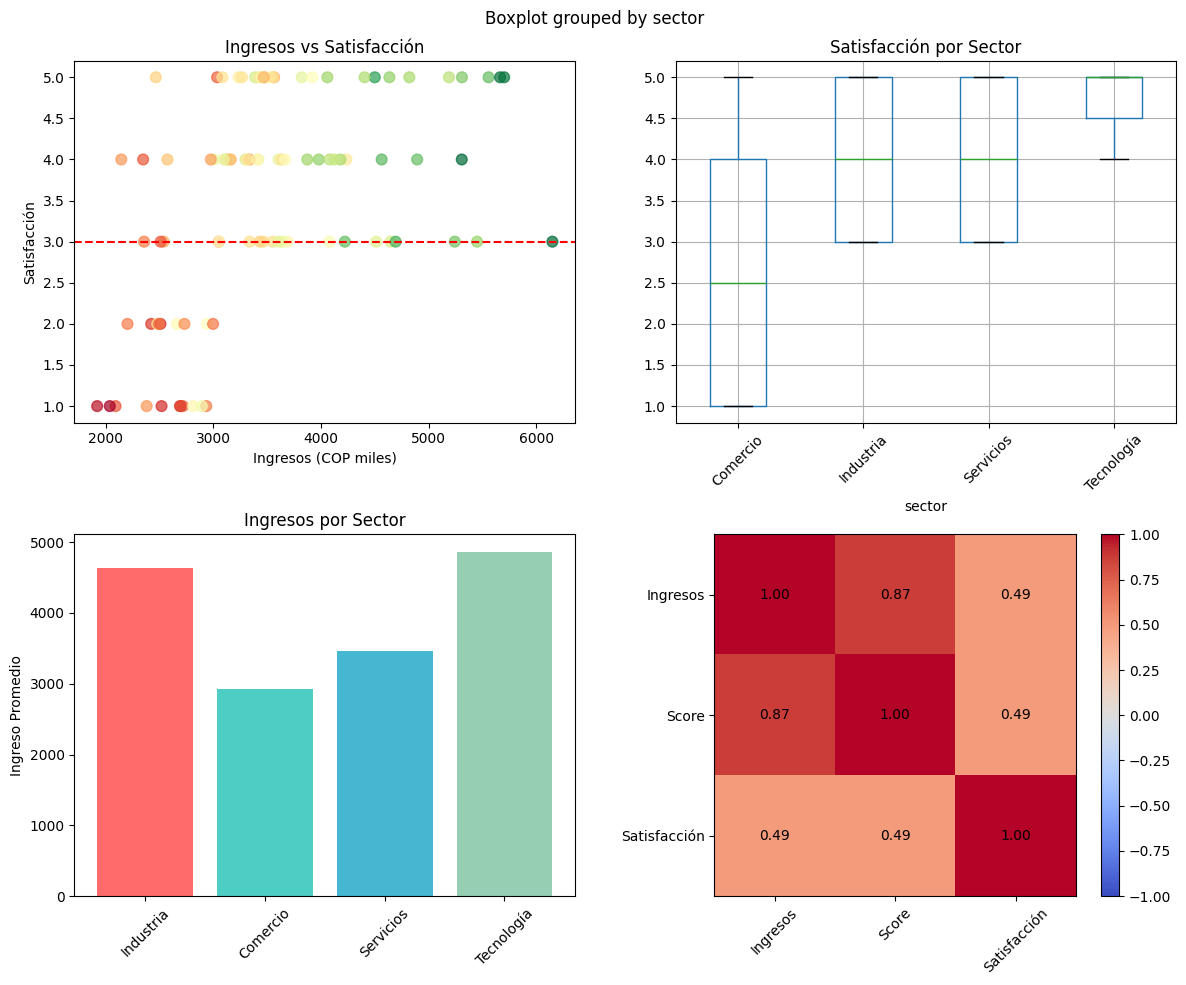


 ¡Taller completado! Guarda este notebook para la próxima clase.


In [48]:

# ---------- PARTE 4: VISUALIZACIÓN ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Análisis de Satisfacción de Clientes', fontsize=14, fontweight='bold')

axes[0,0].scatter(df['ingresos_mensuales_cop'], df['satisfaccion'], 
                  c=df['score_credito'], cmap='RdYlGn', s=60, alpha=0.7)
axes[0,0].set_xlabel('Ingresos (COP miles)')
axes[0,0].set_ylabel('Satisfacción')
axes[0,0].set_title('Ingresos vs Satisfacción')
axes[0,0].axhline(y=3, color='red', linestyle='--')

df.boxplot(column='satisfaccion', by='sector', ax=axes[0,1])
axes[0,1].set_title('Satisfacción por Sector')
axes[0,1].tick_params(axis='x', rotation=45)

sectores_u = df['sector'].unique()
medias = [df[df['sector']==s]['ingresos_mensuales_cop'].mean() for s in sectores_u]
axes[1,0].bar(range(len(sectores_u)), medias, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1,0].set_xticks(range(len(sectores_u)))
axes[1,0].set_xticklabels(sectores_u, rotation=45)
axes[1,0].set_ylabel('Ingreso Promedio')
axes[1,0].set_title('Ingresos por Sector')

corr = df[['ingresos_mensuales_cop', 'score_credito', 'satisfaccion']].corr()
im = axes[1,1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(3))
axes[1,1].set_yticks(range(3))
axes[1,1].set_xticklabels(['Ingresos', 'Score', 'Satisfacción'], rotation=45)
axes[1,1].set_yticklabels(['Ingresos', 'Score', 'Satisfacción'])
for i in range(3):
    for j in range(3):
        axes[1,1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im, ax=axes[1,1])
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\analisis_clientes.png", dpi=300)
plt.show()

print("\n ¡Taller completado! Guarda este notebook para la próxima clase.")


# Hoja de Respuesta para Estudiantes



# TALLER PREVIO: ANÁLISIS DE DATOS
## Nombre: ______________________ Fecha: ______________

### RESPUESTAS:

**1. Sector con menor satisfacción promedio:** ________________

**2. Correlación ingresos-satisfacción:** ______
   - ¿Qué significa este valor? _______________________________________________

**3. Sector con mejor score de crédito:** ________________
   - Posible explicación: ____________________________________________________

**4. Clientes insatisfechos:** ______ de ______ (______%)
   - ¿Qué patrón observas en estos clientes? _________________________________

**5. Recomendaciones para la empresa:**
   1. ________________________________________________________________
   2. ________________________________________________________________
   3. ________________________________________________________________

### PREGUNTA EXTRA (Análisis propio):
¿Qué otra relación entre variables te gustaría explorar? _______________________
___________________________________________________________________________




## Expectativas para la Clase Principal

Al llegar a clase, los estudiantes deben tener:
1.  El dataset generado y limpio
2.  Las visualizaciones básicas creadas
2.  Respuestas preliminares a las 5 preguntas
3.  Al menos 1 observación interesante no solicitada



**La clase principal se enfocará en:**
- Discutir los hallazgos en grupo
- Comparar diferentes estrategias de limpieza
- Introducir técnicas avanzadas (regresión, clustering)
- Aplicar los resultados a un caso de negocio real

